In [1]:
try:
    import google.colab  # noqa: F401

    # specify the version of DataEval (==X.XX.X) for versions other than the latest
    %pip install -q dataeval maite-datasets matplotlib
except Exception:
    pass

In [2]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from maite_datasets.multiobject_tracking import to_multiobject_tracking_dataset
from maite_datasets.object_detection import SeaDrone

from dataeval import Metadata
from dataeval.config import set_max_processes
from dataeval.core import compute_stats
from dataeval.data import Limit, Resize, SourceLocator, View
from dataeval.flags import ImageStats
from dataeval.quality import Outliers
from dataeval.types import SourceIndex

set_max_processes(1)

In [3]:
dataset = View(SeaDrone(root="./data", image_set="val", download=True), Limit(50))
print(dataset)

View Dataset
------------
    Operations: [Limit(size=50)]
    Selected Size: 50

SeaDrone Dataset
----------------
    Transforms: []
    Image Set: val
    Metadata: {'id': 'SeaDrone_val', 'index2label': {0: 'not_used', 1: 'swimmer', 2: 'boat', 3: 'jetski', 4: 'life_saving_appliances', 5: 'buoy'}, 'split': 'val'}
    Path: /builds/jatic/aria/dataeval/docs/source/notebooks/data/seadrone
    Size: 1547


In [4]:
stats = compute_stats(
    dataset, stats=ImageStats.DIMENSION | ImageStats.VISUAL, per_target=True, normalize_pixel_values=False
)
outliers = Outliers().from_stats(stats, per_target=True)

for address, metrics in list(outliers.outliers.items())[:5]:
    print(f"{address!r:<24} {', '.join(metrics)}")

SourceIndex(19, 0)       size
SourceIndex(20, 0)       size
SourceIndex(21, 0)       size
SourceIndex(23, 0)       size
SourceIndex(24)          width


In [5]:
detections = [a for a in outliers.outliers if a.key is not None]
whole_images = [a for a in outliers.outliers if a.key is None]
print(f"{len(detections)} detection findings, {len(whole_images)} whole-image findings")

# Pick a flagged detection whose image holds several, so there is something to compare it against. Which detections a
# linter flags depends on the data, so fall back to the first detection of the busiest image when it flags none.
per_item = Counter(index.item for index in stats["source_index"] if index.key is not None)
if detections:
    address = max(detections, key=lambda a: per_item[a.item])
else:
    address = next(a for a in stats["source_index"] if a.item == per_item.most_common(1)[0][0] and a.key is not None)

print(f"\nitem  = {address.item}")
print(f"key   = {address.key}")
print(f"level = {address.level}   (unstated)")
print(f"str   = {address}")

16 detection findings, 3 whole-image findings

item  = 41
key   = 0
level = None   (unstated)
str   = 41/0


In [6]:
locator = SourceLocator(dataset)

print(f"item_level = {locator.item_level}")
print(f"levels     = {locator.levels}")

found = locator[address]
print(f"\n{address!r} is a {found.level}")
print(f"  box   = {found.box}")
print(f"  label = {found.label}")
print(f"  image = {found.pixels.shape}")

# An accessor a level does not carry raises rather than answering None, so a mistake is a
# message instead of a null propagating into a plot. Branch on `.level` for mixed findings.
whole_image = whole_images[0] if whole_images else SourceIndex(address.item)
try:
    _ = locator[whole_image].box
except TypeError as error:
    print(f"\n{whole_image!r}.box -> {error}")

item_level = unit
levels     = ('unit', 'instance')

SourceIndex(41, 0) is a instance
  box   = [824. 772. 942. 848.]
  label = 2
  image = (3, 933, 1229)

SourceIndex(24).box -> SourceIndex(24) is at 'unit' level and names no single detection. Use `within('instance')` for the detections inside it.


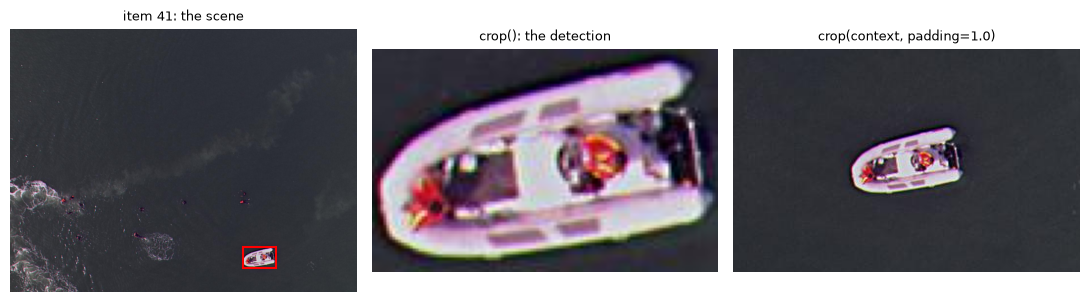

In [7]:
def show(axis, pixels, title, box=None):
    """Draw a (C, H, W) array, optionally with a box on it."""
    axis.imshow(np.transpose(pixels, (1, 2, 0)).astype(np.uint8))
    axis.set_title(title, fontsize=9)
    axis.axis("off")
    if box is not None:
        x0, y0, x1, y1 = box
        axis.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, color="red", linewidth=1.5))


fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
show(axes[0], found.pixels, f"item {found.item_index}: the scene", box=found.box)
show(axes[1], found.crop(), "crop(): the detection")
show(axes[2], found.crop(region="context", padding=1.0), "crop(context, padding=1.0)")
plt.tight_layout()
plt.show()

In [8]:
scene = found.at("unit")
print(f"{found.address!r} sits in {scene.address!r}")

siblings = scene.within("instance")
print(f"item {scene.item_index} holds {len(siblings)} detection(s):")

flagged = set(outliers.outliers)
for sibling in siblings:
    mark = "<- flagged" if sibling.address in flagged else ""
    print(f"  {sibling.address!r:<20} key={sibling.key:<4} label={sibling.label:<3} {mark}")

SourceIndex(41, 0) sits in SourceIndex(41)
item 41 holds 11 detection(s):
  SourceIndex(41, 0)   key=0    label=2   <- flagged
  SourceIndex(41, 1)   key=1    label=1   
  SourceIndex(41, 2)   key=2    label=1   
  SourceIndex(41, 3)   key=3    label=1   
  SourceIndex(41, 4)   key=4    label=1   
  SourceIndex(41, 5)   key=5    label=1   
  SourceIndex(41, 6)   key=6    label=1   
  SourceIndex(41, 7)   key=7    label=1   
  SourceIndex(41, 8)   key=8    label=1   
  SourceIndex(41, 9)   key=9    label=1   
  SourceIndex(41, 10)  key=10   label=1   


In [9]:
resized = View(dataset, Resize(128))
on_resized = SourceLocator(resized)[SourceIndex(found.item_index, found.key)]

print(f"measured shape  = {on_resized.pixels.shape}")
print(f"source shape    = {on_resized.source_pixels.shape}")
print(f"measured box    = {np.round(on_resized.box, 1)}")
print(f"source box      = {np.round(on_resized.source_datum[1].boxes[found.key], 1)}")
print(f"source item     = {on_resized.source_item_index}")

measured shape  = (3, 128, 169)
source shape    = (3, 933, 1229)
measured box    = [113.3 105.9 129.5 116.3]
source box      = [824. 772. 942. 848.]
source item     = 41


/builds/jatic/aria/dataeval/src/dataeval/utils/_array.py:325: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  tensor = torch.as_tensor(np.asarray(image)).float()


In [10]:
videos = to_multiobject_tracking_dataset(
    videos=[np.zeros((3, 3, 48, 48), dtype=np.uint8)],
    labels=[[[0, 1], [], [1]]],
    bboxes=[[[[1, 1, 8, 8], [10, 10, 20, 20]], [], [[12, 12, 22, 22]]]],
    track_ids=[[[5, 9], [], [9]]],
    metadata=None,
    classes=["diver", "boat"],
    name="toy-tracking",
)

tracking = SourceLocator(videos)
print(f"item_level = {tracking.item_level}")
print(f"levels     = {tracking.levels}")

item_level = sequence
levels     = ('sequence', 'unit', 'track', 'instance')


In [11]:
sequence = tracking[SourceIndex(0)]
print(f"{sequence.address!r} is a {sequence.level} and holds:")
for level in ("unit", "track", "instance"):
    inside = sequence.within(level)
    print(f"  {len(inside)} {level}: {[item.address for item in inside]}")

SourceIndex(0) is a sequence and holds:
  3 unit: [SourceIndex(0, 0, 'unit'), SourceIndex(0, 1, 'unit'), SourceIndex(0, 2, 'unit')]
  2 track: [SourceIndex(0, 5, 'track'), SourceIndex(0, 9, 'track')]
  3 instance: [SourceIndex(0, 0), SourceIndex(0, 1), SourceIndex(0, 2)]


In [12]:
detection = tracking[SourceIndex(0, 2)]
print(f"{detection.address!r} label={detection.label} box={detection.box}")
print(f"  seen in    {detection.at('unit').address!r}")
print(f"  belongs to {detection.at('track').address!r}")
print(f"  came from  {detection.at('sequence').address!r}")

track = detection.at("track")
observations = track.within("instance")
print(f"\ntrack {track.key} was observed {len(observations)} times:")
for observation in observations:
    print(f"  {observation.address!r} in frame {observation.at('unit').key}, box {observation.box}")

SourceIndex(0, 2) label=1 box=[12. 12. 22. 22.]
  seen in    SourceIndex(0, 2, 'unit')
  belongs to SourceIndex(0, 9, 'track')
  came from  SourceIndex(0)

track 9 was observed 2 times:
  SourceIndex(0, 1) in frame 0, box [10. 10. 20. 20.]
  SourceIndex(0, 2) in frame 2, box [12. 12. 22. 22.]


In [13]:
metadata = Metadata(dataset)
metadata.add_factors(stats)

addresses = list(stats["source_index"])
metadata.add_factors(
    {"is_outlier": [address in flagged for address in addresses]},
    source_index=addresses,
)

rows = metadata.rows_at("instance")
print(rows.select("item_index", "target_index", "instance_is_outlier").head(5))
print(f"\nflagged {rows['instance_is_outlier'].sum()} of {rows.height} instance rows")

shape: (5, 3)
┌────────────┬──────────────┬─────────────────────┐
│ item_index ┆ target_index ┆ instance_is_outlier │
│ ---        ┆ ---          ┆ ---                 │
│ i64        ┆ i64          ┆ bool                │
╞════════════╪══════════════╪═════════════════════╡
│ 0          ┆ 0            ┆ false               │
│ 1          ┆ 0            ┆ false               │
│ 1          ┆ 1            ┆ false               │
│ 1          ┆ 2            ┆ false               │
│ 1          ┆ 3            ┆ false               │
└────────────┴──────────────┴─────────────────────┘

flagged 16 of 143 instance rows


/tmp/ipykernel_331148/4108792088.py:2: UserWarning: `date_time` was dropped: nearly every row holds a different value, so the column identifies rows rather than grouping them, and it is not numeric so there is no order along which to cut it into groups. Map the values onto a smaller vocabulary to keep the factor. See Metadata.dropped_factors.
  metadata.add_factors(stats)
/tmp/ipykernel_331148/4108792088.py:10: UserWarning: `altitude`, `frame`, `instance_aspect_ratio`, `instance_brightness`, `instance_contrast`, `instance_darkness`, `instance_distance_center`, `instance_distance_edge`, `instance_height`, `instance_offset_x`, `instance_offset_y`, `instance_sharpness`, `instance_size`, `instance_width`, `object_id`, `object_size`, `unit_brightness`, `unit_contrast`, `unit_darkness` and `unit_sharpness` were binned automatically ('uniform_width') because no bins were declared. The bin count is derived from the data, so it is not stable across samples and the same factor measured twice may